# 🤖 Modeling — Sentiment Analysis Blu by BCA Digital

Notebook ini melatih model klasifikasi sentimen menggunakan fitur dari `5b-FeatureEngineering-ForModeling.ipynb`.

**Alur:**
```
5b (Feature Eng) → fit TF-IDF pada X_train → simpan vectorizer.pkl + split_info.pkl
6  (Modeling)    → load vectorizer.pkl      → langsung training, tanpa re-fit TF-IDF
```

**Model yang dibandingkan:**
- Logistic Regression
- Naive Bayes (MultinomialNB)
- Support Vector Machine (LinearSVC)
- Random Forest

## 1. Import Library

In [32]:
import pandas as pd
import numpy as np
import pickle
import os

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../data', exist_ok=True)
os.makedirs('../data/visualisasi', exist_ok=True)
plt.rcParams['figure.dpi'] = 120
print('✅ Library siap!')

✅ Library siap!


## 2. Load Data + Vectorizer dari Feature Engineering

Vectorizer sudah di-fit pada train set di notebook `5b`. Di sini kita tinggal load dan transform — tidak ada fit ulang.

In [33]:
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/blu_modeling_ready.csv')

with open('../data/tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

with open('../data/train_test_split_info.pkl', 'rb') as f:
    split_info = pickle.load(f)

TEXT_COL  = split_info['text_col']
LABEL_COL = split_info['label_col']

# ── Fix 1: hapus duplikat sebelum split
before = len(df)
df = df.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
print(f'Duplikat dihapus: {before - len(df)} baris')
print(f'Data bersih     : {len(df):,} baris')

X = df[TEXT_COL]
y = df[LABEL_COL]

# ── Fix 2: split dengan index bersih
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

# Verifikasi
overlap_idx  = set(X_train.index) & set(X_test.index)
overlap_teks = set(X_train.values) & set(X_test.values)
print(f'\nOverlap index : {len(overlap_idx)}')   # harus 0
print(f'Overlap teks  : {len(overlap_teks)}')   # harus 0 atau sangat kecil

print(f'\nTrain : {len(X_train):,}')
print(f'Test  : {len(X_test):,}')
print('\nDistribusi train:')
print(y_train.value_counts())

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

Duplikat dihapus: 6354 baris
Data bersih     : 18,179 baris

Overlap index : 0
Overlap teks  : 0

Train : 14,543
Test  : 3,636

Distribusi train:
sentiment
positif    8665
negatif    5878
Name: count, dtype: int64


In [34]:
# Tambahkan ini di awal section training untuk verifikasi
print('Sumber X_train_tfidf:', X_train_tfidf.shape)
print('Sumber X_test_tfidf :', X_test_tfidf.shape)
print()

# Cek overlap index
train_idx = set(range(X_train_tfidf.shape[0]))  # jika dari CSV oversampled
# atau jika dari split_info:
# train_idx = set(split_info['train_index'])
test_idx  = set(split_info['test_index'])
print(f'Test index min : {min(test_idx)}, max : {max(test_idx)}')
print(f'Train size     : {X_train_tfidf.shape[0]}')

Sumber X_train_tfidf: (14543, 7928)
Sumber X_test_tfidf : (3636, 7928)

Test index min : 4, max : 24530
Train size     : 14543


In [35]:
# ── DIAGNOSIS: cek isi split_info ──
print('Keys di split_info:', list(split_info.keys()))
print(f'n_train di pkl : {split_info["n_train"]}')
print(f'n_test  di pkl : {split_info["n_test"]}')
print(f'train_index len: {len(split_info["train_index"])}')
print(f'test_index  len: {len(split_info["test_index"])}')
print()

# Cek apakah train_index mengandung angka > 24753 (index hasil oversampling)
train_idx_list = split_info['train_index']
print(f'train_index min: {min(train_idx_list)}')
print(f'train_index max: {max(train_idx_list)}')  # kalau > 24753 → masalah ada di sini
print()

# Cek overlap
overlap = set(train_idx_list) & set(split_info['test_index'])
print(f'Overlap train-test: {len(overlap)}')  # harus 0

Keys di split_info: ['train_index', 'test_index', 'random_state', 'test_size', 'text_col', 'label_col', 'n_train', 'n_test']
n_train di pkl : 19626
n_test  di pkl : 4907
train_index len: 19626
test_index  len: 4907

train_index min: 0
train_index max: 19625

Overlap train-test: 3961


## 3. Distribusi Label

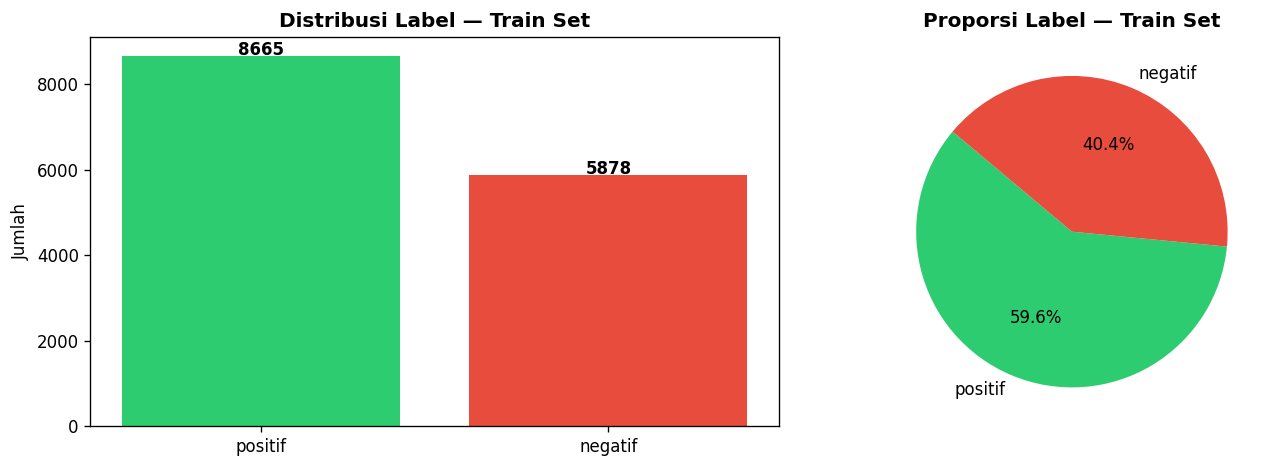

In [36]:
COLORS = {'positif': '#2ECC71', 'netral': '#F39C12', 'negatif': '#E74C3C'}
ORDER  = [l for l in ['positif', 'netral', 'negatif'] if l in y.unique()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = y_train.value_counts()
axes[0].bar([x for x in ORDER if x in counts.index],
            [counts.get(x, 0) for x in ORDER if x in counts.index],
            color=[COLORS[x] for x in ORDER if x in counts.index])
axes[0].set_title('Distribusi Label — Train Set', fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, lbl in enumerate([x for x in ORDER if x in counts.index]):
    axes[0].text(i, counts[lbl] + 20, str(counts[lbl]), ha='center', fontweight='bold')

pie_labels = [x for x in ORDER if x in counts.index]
axes[1].pie([counts.get(x, 0) for x in pie_labels],
            labels=pie_labels,
            colors=[COLORS[x] for x in pie_labels],
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Proporsi Label — Train Set', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/visualisasi/distribusi_label_train.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Definisi Model

Tidak ada TF-IDF di sini — vectorizer sudah dihandle di Section 2.

In [37]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, random_state=42
    ),
    'Naive Bayes': MultinomialNB(
        alpha=0.1
    ),
    'SVM (LinearSVC)': LinearSVC(
        C=1.0, max_iter=2000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
}

print(f'Total model: {len(models)}')
for name in models:
    print(f'  - {name}')

Total model: 4
  - Logistic Regression
  - Naive Bayes
  - SVM (LinearSVC)
  - Random Forest


## 5. Training & Evaluasi Semua Model

In [47]:
results = {}
trained_models = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in models.items():
    print(f'\n{"="*60}')
    print(f'  Training: {name}')
    print(f'{"="*60}')

    # CV langsung tanpa oversample
    cv_scores = cross_val_score(
        clf, X_train_tfidf, y_train,
        cv=skf, scoring='f1_macro', n_jobs=-1
    )
    print(f'CV Macro F1 (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    # Fit langsung tanpa oversample
    clf.fit(X_train_tfidf, y_train)
    trained_models[name] = clf

    y_pred = clf.predict(X_test_tfidf)
    acc  = accuracy_score(y_test, y_pred)
    f1w  = f1_score(y_test, y_pred, average='weighted')
    f1m  = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, average='macro')
    rec  = recall_score(y_test, y_pred, average='macro')

    results[name] = {
        'accuracy'   : acc,
        'f1_weighted': f1w,
        'f1_macro'   : f1m,
        'cv_f1_mean' : cv_scores.mean(),
        'cv_f1_std'  : cv_scores.std(),
        'y_pred'     : y_pred,
    }

    print(f'Accuracy         : {acc*100:.2f}%')
    print(f'Precision Macro  : {prec:.4f}')
    print(f'Recall Macro     : {rec:.4f}')
    print(f'F1 Macro         : {f1m:.4f}')
    print(f'F1 Weighted      : {f1w:.4f}')
    print(f'Classification Report:')
    print(classification_report(y_test, y_pred))


  Training: Logistic Regression
CV Macro F1 (5-fold): 0.8598 ± 0.0042
Accuracy         : 85.07%
Precision Macro  : 0.8472
Recall Macro     : 0.8408
F1 Macro         : 0.8436
F1 Weighted      : 0.8500
Classification Report:
              precision    recall  f1-score   support

     negatif       0.83      0.79      0.81      1469
     positif       0.86      0.89      0.88      2167

    accuracy                           0.85      3636
   macro avg       0.85      0.84      0.84      3636
weighted avg       0.85      0.85      0.85      3636


  Training: Naive Bayes
CV Macro F1 (5-fold): 0.8531 ± 0.0039
Accuracy         : 84.46%
Precision Macro  : 0.8379
Recall Macro     : 0.8421
F1 Macro         : 0.8397
F1 Weighted      : 0.8451
Classification Report:
              precision    recall  f1-score   support

     negatif       0.80      0.83      0.81      1469
     positif       0.88      0.86      0.87      2167

    accuracy                           0.84      3636
   macro avg   

## 6. Perbandingan Performa

In [48]:
comparison_df = pd.DataFrame([
    {
        'Model'       : name,
        'Accuracy'    : f"{res['accuracy']*100:.2f}%",
        'F1 Weighted' : f"{res['f1_weighted']:.4f}",
        'CV F1 Mean'  : f"{res['cv_f1_mean']:.4f}",
        'CV F1 Std'   : f"±{res['cv_f1_std']:.4f}",
    }
    for name, res in results.items()
]).sort_values('F1 Weighted', ascending=False).reset_index(drop=True)

print('📊 Perbandingan Performa:')
display(comparison_df)

📊 Perbandingan Performa:


,Model,Accuracy,F1 Weighted,CV F1 Mean,CV F1 Std
0,Logistic Regression,85.07%,0.8500,0.8598,±0.0042
1,SVM (LinearSVC),84.82%,0.8480,0.8517,±0.0053
2,Naive Bayes,84.46%,0.8451,0.8531,±0.0039
3,Random Forest,84.10%,0.8413,0.8490,±0.0055


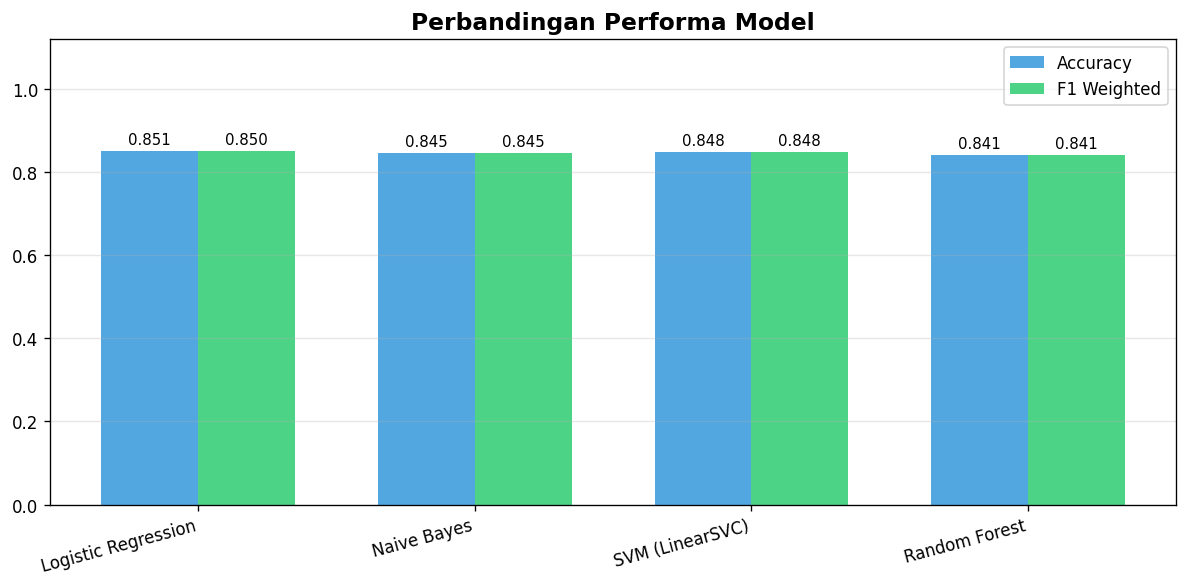

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))
model_names = list(results.keys())
x = np.arange(len(model_names))
w = 0.35

b1 = ax.bar(x - w/2, [results[m]['accuracy'] for m in model_names],
            w, label='Accuracy', color='#3498DB', alpha=0.85)
b2 = ax.bar(x + w/2, [results[m]['f1_weighted'] for m in model_names],
            w, label='F1 Weighted', color='#2ECC71', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.12)
ax.set_title('Perbandingan Performa Model', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../data/visualisasi/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Pilih Best Model & Simpan

In [50]:
best_name   = max(results, key=lambda m: results[m]['f1_weighted'])
best_clf    = trained_models[best_name]
best_result = results[best_name]

print(f'🏆 Best Model  : {best_name}')
print(f'   Accuracy    : {best_result["accuracy"]*100:.2f}%')
print(f'   F1 Weighted : {best_result["f1_weighted"]:.4f}')
print(f'   CV F1 Mean  : {best_result["cv_f1_mean"]:.4f} ± {best_result["cv_f1_std"]:.4f}')

🏆 Best Model  : Logistic Regression
   Accuracy    : 85.07%
   F1 Weighted : 0.8500
   CV F1 Mean  : 0.8598 ± 0.0042


In [51]:
# Simpan best model + vectorizer dalam 1 bundle
# Keduanya disimpan bersama supaya inference selalu konsisten
bundle = {
    'classifier'   : best_clf,
    'vectorizer'   : vectorizer,
    'model_name'   : best_name,
    'label_classes': sorted(y.unique().tolist()),
}

with open('../data/best_model_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)
print('✅ Bundle (classifier + vectorizer) disimpan: ../data/best_model_bundle.pkl')

✅ Bundle (classifier + vectorizer) disimpan: ../data/best_model_bundle.pkl


In [52]:
# Simpan hasil prediksi test set untuk Evaluation notebook
test_results_df = X_test.to_frame()
test_results_df['true_label']      = y_test.values
test_results_df['predicted_label'] = best_result['y_pred']
test_results_df['is_correct']      = (
    test_results_df['true_label'] == test_results_df['predicted_label']
)
test_results_df.to_csv('../data/test_predictions.csv', index=False)
print('✅ Prediksi test set disimpan: ../data/test_predictions.csv')
test_results_df.head(5)

✅ Prediksi test set disimpan: ../data/test_predictions.csv


,final_content,true_label,predicted_label,is_correct
10230,verifikasi email susah banget suruh disebutin ...,negatif,negatif,True
2877,autodebit posko,positif,positif,True
2199,ui berat suka force close android,negatif,negatif,True
11383,baru lola hapusin lai memori d hapusin hp d re...,negatif,negatif,True
14550,kasih gratis biaya transfer kasih bintang nih,positif,positif,True


## 8. Uji Prediksi Manual

In [53]:
# Cara pakai bundle untuk prediksi teks baru
sample_reviews = [
    "saya menemukan aplikasi ini dari teman saya",
    "aplikasi sering error tidak bisa login sama sekali",
    "lumayan oke tapi masih ada beberapa bug",
    "blu digital sangat membantu untuk transaksi sehari-hari",
    "lambat banget loading nya, bikin frustrasi"
]

X_sample    = vectorizer.transform(sample_reviews)
preds       = best_clf.predict(X_sample)
proba       = best_clf.predict_proba(X_sample)   # RF selalu punya ini
classes     = best_clf.classes_
confidences = proba.max(axis=1)

print(f'🔮 Hasil Prediksi Manual (model: {best_name}):\n')
emoji_map = {'positif': '😊', 'negatif': '😡', 'netral': '😐'}

for i, (review, pred, conf) in enumerate(zip(sample_reviews, preds, confidences)):
    print(f'{emoji_map.get(pred, "🤔")} [{pred.upper()}] {conf*100:.1f}% confidence')
    print(f'   "{review}"')

    breakdown = {cls: proba[i][j] for j, cls in enumerate(classes)}
    breakdown_sorted = sorted(breakdown.items(), key=lambda x: x[1], reverse=True)
    bar_parts = [f'{emoji_map.get(c,"?")} {c}: {p*100:.1f}%' for c, p in breakdown_sorted]
    print(f'   └─ {" | ".join(bar_parts)}')
    print()

🔮 Hasil Prediksi Manual (model: Logistic Regression):

😊 [POSITIF] 64.5% confidence
   "saya menemukan aplikasi ini dari teman saya"
   └─ 😊 positif: 64.5% | 😡 negatif: 35.5%

😊 [POSITIF] 55.6% confidence
   "aplikasi sering error tidak bisa login sama sekali"
   └─ 😊 positif: 55.6% | 😡 negatif: 44.4%

😊 [POSITIF] 87.7% confidence
   "lumayan oke tapi masih ada beberapa bug"
   └─ 😊 positif: 87.7% | 😡 negatif: 12.3%

😊 [POSITIF] 74.3% confidence
   "blu digital sangat membantu untuk transaksi sehari-hari"
   └─ 😊 positif: 74.3% | 😡 negatif: 25.7%

😡 [NEGATIF] 86.4% confidence
   "lambat banget loading nya, bikin frustrasi"
   └─ 😡 negatif: 86.4% | 😊 positif: 13.6%

